# <font style="color:blue">Project 3: Object Detection</font>

#### Maximum Points: 100

<div><table>
<tr><td><h3>Sr. no.</h3></td><td><h3>Section</h3></td><td><h3>Points</h3></td></tr>
<tr><td><h3>1</h3></td><td><h3>Plot Ground Truth Bounding Boxes</h3></td><td><h3>20</h3></td></tr>
<tr><td><h3>2</h3></td><td><h3>Training</h3></td><td><h3>25</h3></td></tr>
<tr><td><h3>3</h3></td><td><h3>Inference</h3></td><td><h3>15</h3></td></tr>
<tr><td><h3>4</h3></td><td><h3>COCO Detection Evaluation</h3></td><td><h3>25</h3></td></tr>
<tr><td><h3>5</h3></td><td><h3>Run Inference on a Video</h3></td><td><h3>15</h3></td></tr>
</table></div>

In [1]:
import sys
!{sys.executable} -m pip install -q opencv-python pycocotools tensorboard torchvision


# <font style="color:purple">Download the Dataset</font>

**[Download the Vehicle registration plate dataset](https://www.dropbox.com/s/k81ljpmzy3fgtx9/Dataset.zip?dl=1)**

Unzip to get:
```
Dataset/
├── train/Vehicle registration plate/  (images + Label/)
└── validation/Vehicle registration plate/  (images + Label/)
```
Each `Label/*.txt` line: `Vehicle registration plate xmin ymin xmax ymax`

**[Download input video](https://www.dropbox.com/s/g88o4dx18zpgn8k/projet3-input-video.mp4?dl=1)**

## Setup: Imports & Configuration

In [2]:
import os, glob, random, json, zipfile, urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.optim as optim
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import MultiStepLR
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.tensorboard import SummaryWriter
from PIL import Image

# pycocotools — install if needed: pip install pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

Using device: cuda


In [3]:
# ── Paths — adjust DATASET_DIR and VIDEO_PATH if needed ───────────────────
DATASET_DIR = 'Dataset'
VIDEO_PATH  = 'projet3-input-video.mp4'   # input video
VIDEO_OUT   = 'output_video.mp4'           # written by Section 5
CHECKPOINT  = 'best_fasterrcnn.pth'
TB_LOG_DIR  = 'runs/license_plate'

TRAIN_DIR = os.path.join(DATASET_DIR, 'train', 'Vehicle registration plate')
VAL_DIR   = os.path.join(DATASET_DIR, 'validation', 'Vehicle registration plate')

CLASS_NAMES = ['__background__', 'Vehicle registration plate']


In [4]:
# ── Auto-download dataset and video if not already present ────────────────
DATASET_ZIP = 'Dataset.zip'
DATASET_URL = 'https://www.dropbox.com/s/k81ljpmzy3fgtx9/Dataset.zip?dl=1'
VIDEO_URL   = 'https://www.dropbox.com/s/g88o4dx18zpgn8k/projet3-input-video.mp4?dl=1'

if not os.path.isdir(DATASET_DIR):
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATASET_URL, DATASET_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall('.')
    print('Dataset ready.')
else:
    print(f'{DATASET_DIR}/ already exists, skipping download.')

if not os.path.exists(VIDEO_PATH):
    print('Downloading input video...')
    urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)
    print('Video ready.')
else:
    print(f'{VIDEO_PATH} already exists, skipping download.')

# ── Discover images now that dataset is present ────────────────────────────
train_imgs = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
val_imgs   = sorted(glob.glob(os.path.join(VAL_DIR,   '*.jpg')))
print(f'Train images: {len(train_imgs)}')
print(f'Val   images: {len(val_imgs)}')


Unzipping...
Dataset ready.
Video ready.
Train images: 5308
Val   images: 386


In [5]:
def img_to_label_path(img_path):
    stem   = os.path.splitext(os.path.basename(img_path))[0]
    parent = os.path.dirname(img_path)
    return os.path.join(parent, 'Label', stem + '.txt')


def parse_label_file(label_path):
    """Return list of [xmin, ymin, xmax, ymax] boxes."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            xmin, ymin, xmax, ymax = map(float, parts[-4:])
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
    return boxes

# <font style="color:green">1. Plot Ground Truth Bounding Boxes [20 Points]</font>

**Three validation images with ground truth bounding boxes.**

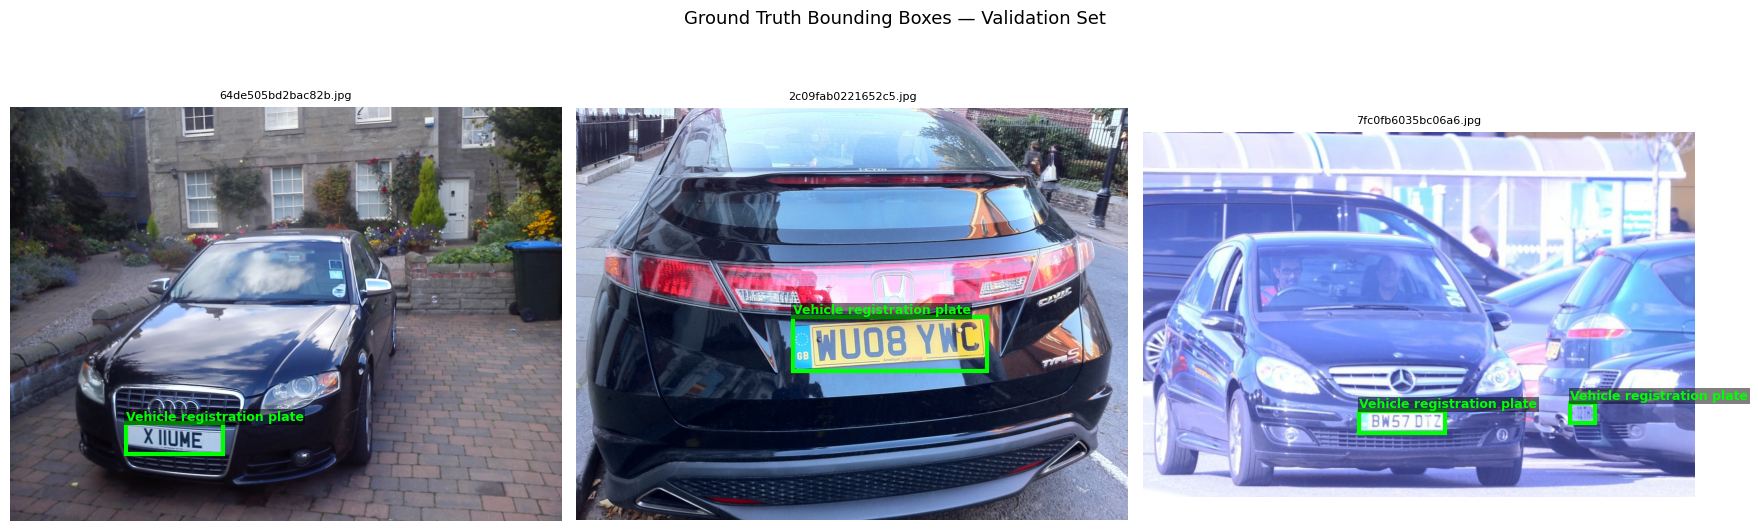

In [6]:
def plot_gt_boxes(img_paths, n=3, seed=7):
    random.seed(seed)
    samples = random.sample(img_paths, n)
    fig, axes = plt.subplots(1, n, figsize=(18, 6))
    for ax, img_path in zip(axes, samples):
        img   = cv2.imread(img_path)
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        boxes = parse_label_file(img_to_label_path(img_path))
        ax.imshow(img)
        for box in boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=3, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(xmin, max(ymin - 5, 10), CLASS_NAMES[1],
                    color='lime', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('Ground Truth Bounding Boxes — Validation Set', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_gt_boxes(val_imgs)

# <font style="color:green">2. Training [25 Points]</font>

Fine-tune **Faster R-CNN** (ResNet-50 FPN, pretrained on COCO) for single-class vehicle registration plate detection.

TensorBoard logs are written to `runs/license_plate`. After training, upload with:
```
tensorboard dev upload --logdir runs/license_plate
```

In [7]:
class LicensePlateDataset(Dataset):
    """
    Dataset for Vehicle Registration Plate detection.
    Only includes images that have at least one bounding box annotation.
    """
    def __init__(self, img_paths):
        self.img_paths = [
            p for p in img_paths
            if len(parse_label_file(img_to_label_path(p))) > 0
        ]

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img_t    = TF.to_tensor(Image.open(img_path).convert('RGB'))

        boxes  = parse_label_file(img_to_label_path(img_path))
        target = {
            'boxes':    torch.tensor(boxes, dtype=torch.float32),
            'labels':   torch.ones(len(boxes), dtype=torch.int64),
            'image_id': torch.tensor([idx]),
        }
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))


BATCH_SIZE  = 4
NUM_WORKERS = 2

train_dataset = LicensePlateDataset(train_imgs)
val_dataset   = LicensePlateDataset(val_imgs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')
print(f'Train batches: {len(train_loader)}')

Train samples: 5308
Val   samples: 386
Train batches: 1327


In [8]:
def build_model(num_classes=2):
    """
    Faster R-CNN (ResNet-50 FPN, COCO pretrained).
    Replace box predictor head for custom class count.
    num_classes = 2: background + vehicle_registration_plate
    """
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_feats = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feats, num_classes)
    return model


model = build_model(num_classes=2).to(DEVICE)
print('Model ready.')
print(f'  Predictor: {model.roi_heads.box_predictor}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/emileneth/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Model ready.
  Predictor: FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)


In [9]:
EPOCHS        = 15
LR            = 5e-3
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4
LR_MILESTONES = [8, 12]

params    = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = MultiStepLR(optimizer, milestones=LR_MILESTONES, gamma=0.1)
writer    = SummaryWriter(log_dir=TB_LOG_DIR)


def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    running = 0.0
    for step, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running += loss.item()
        global_step = (epoch - 1) * len(loader) + step
        writer.add_scalar('Loss/train_step', loss.item(), global_step)
        for k, v in loss_dict.items():
            writer.add_scalar(f'Loss/{k}', v.item(), global_step)

    return running / len(loader)


best_loss    = float('inf')
train_losses = []

for epoch in range(1, EPOCHS + 1):
    avg = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch)
    scheduler.step()
    train_losses.append(avg)
    writer.add_scalar('Loss/train_epoch', avg, epoch)
    print(f'Epoch [{epoch:02d}/{EPOCHS}]  Loss: {avg:.4f}'
          f'  LR: {scheduler.get_last_lr()[0]:.2e}')

    if avg < best_loss:
        best_loss = avg
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  ✓ checkpoint saved')

writer.close()
print(f'\nTraining complete. Best loss: {best_loss:.4f}')

Epoch [01/15]  Loss: 0.1310  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [02/15]  Loss: 0.1120  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [03/15]  Loss: 0.1067  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [04/15]  Loss: 0.1015  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [05/15]  Loss: 0.0985  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [06/15]  Loss: 0.0947  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [07/15]  Loss: 0.0912  LR: 5.00e-03
  ✓ checkpoint saved
Epoch [08/15]  Loss: 0.0904  LR: 5.00e-04
  ✓ checkpoint saved
Epoch [09/15]  Loss: 0.0740  LR: 5.00e-04
  ✓ checkpoint saved
Epoch [10/15]  Loss: 0.0703  LR: 5.00e-04
  ✓ checkpoint saved
Epoch [11/15]  Loss: 0.0679  LR: 5.00e-04
  ✓ checkpoint saved
Epoch [12/15]  Loss: 0.0656  LR: 5.00e-05
  ✓ checkpoint saved
Epoch [13/15]  Loss: 0.0624  LR: 5.00e-05
  ✓ checkpoint saved
Epoch [14/15]  Loss: 0.0621  LR: 5.00e-05
  ✓ checkpoint saved
Epoch [15/15]  Loss: 0.0618  LR: 5.00e-05
  ✓ checkpoint saved

Training complete. Best loss: 0.0618


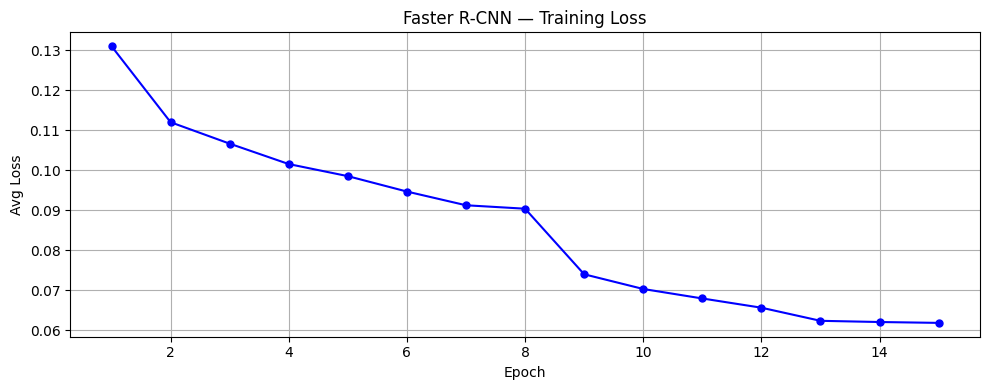

TensorBoard logs: runs/license_plate
Share: tensorboard dev upload --logdir runs/license_plate


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', markersize=5)
plt.xlabel('Epoch'); plt.ylabel('Avg Loss')
plt.title('Faster R-CNN — Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'TensorBoard logs: {TB_LOG_DIR}')
print('Share: tensorboard dev upload --logdir', TB_LOG_DIR)

# <font style="color:green">3. Inference [15 Points]</font>

**Predictions on three validation images using the trained model.**

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()
print('Best model loaded.')

Best model loaded.


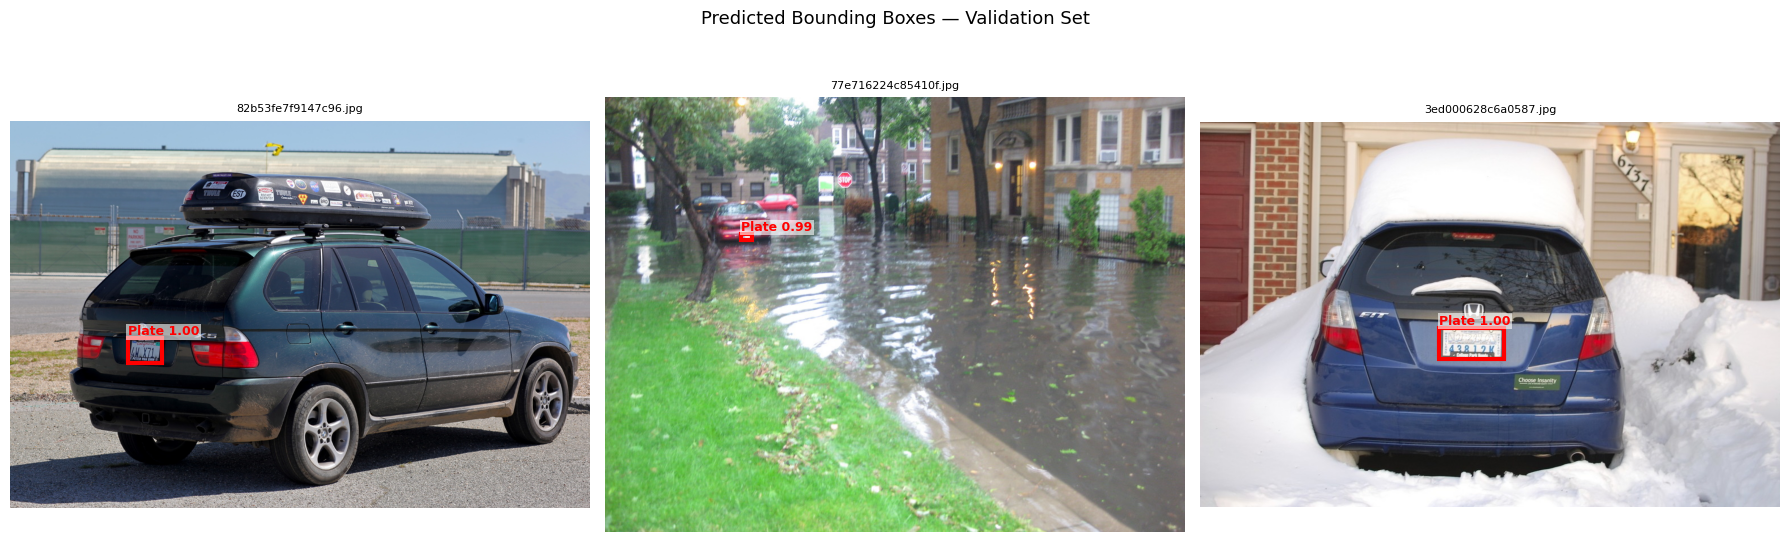

In [12]:
SCORE_THRESHOLD = 0.5


def predict(model, img_path, threshold=SCORE_THRESHOLD, device=DEVICE):
    img_t = TF.to_tensor(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(img_t)[0]
    keep  = preds['scores'] >= threshold
    return {
        'boxes':  preds['boxes'][keep].cpu().numpy(),
        'labels': preds['labels'][keep].cpu().numpy(),
        'scores': preds['scores'][keep].cpu().numpy(),
    }


def plot_predictions(img_paths, n=3, seed=99):
    random.seed(seed)
    samples = random.sample(img_paths, n)
    fig, axes = plt.subplots(1, n, figsize=(18, 6))
    for ax, img_path in zip(axes, samples):
        img   = cv2.imread(img_path)
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        preds = predict(model, img_path)
        ax.imshow(img)
        for box, score in zip(preds['boxes'], preds['scores']):
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=3, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            label = f'Plate {score:.2f}'
            ax.text(xmin, max(ymin - 5, 10), label,
                    color='red', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('Predicted Bounding Boxes — Validation Set', fontsize=13)
    plt.tight_layout()
    plt.show()


plot_predictions(val_imgs)

# <font style="color:green">4. COCO Detection Evaluation [25 Points]</font>

Evaluate with the standard COCO detection protocol.

#### <font style="color:red">Required: AP @[IoU=0.50:0.95] > 0.5</font>

In [13]:
def build_coco_gt(img_paths):
    """Convert label files to COCO ground-truth format."""
    images, anns = [], []
    ann_id = 1
    for img_id, img_path in enumerate(img_paths, start=1):
        img  = Image.open(img_path)
        W, H = img.size
        images.append({'id': img_id, 'file_name': os.path.basename(img_path),
                        'width': W, 'height': H})
        for box in parse_label_file(img_to_label_path(img_path)):
            xmin, ymin, xmax, ymax = box
            w, h = xmax - xmin, ymax - ymin
            anns.append({'id': ann_id, 'image_id': img_id, 'category_id': 1,
                          'bbox': [xmin, ymin, w, h], 'area': w * h, 'iscrowd': 0})
            ann_id += 1
    return {
        'images': images, 'annotations': anns,
        'categories': [{'id': 1, 'name': 'Vehicle registration plate'}]
    }


def build_dt_list(model, img_paths, threshold=0.05, device=DEVICE):
    """Run inference and return COCO-format detection list."""
    results = []
    model.eval()
    for img_id, img_path in enumerate(img_paths, start=1):
        img_t = TF.to_tensor(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model(img_t)[0]
        for box, score, label in zip(preds['boxes'], preds['scores'], preds['labels']):
            if score < threshold:
                continue
            xmin, ymin, xmax, ymax = box.cpu().tolist()
            results.append({'image_id': img_id, 'category_id': int(label),
                             'bbox': [xmin, ymin, xmax-xmin, ymax-ymin],
                             'score': float(score)})
    return results


print('Building COCO ground truth...')
gt_dict = build_coco_gt(val_dataset.img_paths)
print(f'  GT images: {len(gt_dict["images"])}, GT anns: {len(gt_dict["annotations"])}')

print('Running inference on validation set...')
dt_list = build_dt_list(model, val_dataset.img_paths)
print(f'  Total detections: {len(dt_list)}')

Building COCO ground truth...
  GT images: 386, GT anns: 512
Running inference on validation set...
  Total detections: 607


In [14]:
# Write temp JSON files and run COCOeval
with open('_coco_gt.json', 'w') as f: json.dump(gt_dict, f)
with open('_coco_dt.json', 'w') as f: json.dump(dt_list, f)

coco_gt   = COCO('_coco_gt.json')
coco_dt   = coco_gt.loadRes('_coco_dt.json')
coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

ap    = coco_eval.stats[0]
ap50  = coco_eval.stats[1]
ap75  = coco_eval.stats[2]
print(f'\nAP  @[IoU=0.50:0.95] = {ap:.3f}')
print(f'AP  @[IoU=0.50]      = {ap50:.3f}')
print(f'AP  @[IoU=0.75]      = {ap75:.3f}')
status = 'PASS ✓' if ap >= 0.5 else 'BELOW TARGET — consider more epochs'
print(f'Status: {status}')

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.594
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.890
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.711
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.336
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.677
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.542
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.657
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

# <font style="color:green">5. Run Inference on a Video [15 Points]</font>

Run detection on every frame and write `output_video.mp4`.

**[Download input video](https://www.dropbox.com/s/g88o4dx18zpgn8k/projet3-input-video.mp4?dl=1)** — save as `projet3-input-video.mp4` in this directory.

#### <font style="color:red">Upload the output video to YouTube and share the link. Do not upload the video in the lab.</font>

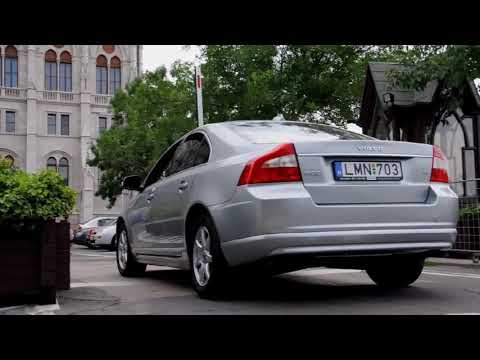

In [15]:
from IPython.display import YouTubeVideo, display
video = YouTubeVideo('DSIJwqNXxpE', width=640, height=360)
display(video)


In [16]:
def run_video_inference(model, video_in, video_out,
                         threshold=SCORE_THRESHOLD, device=DEVICE):
    """
    Read video frame-by-frame, run Faster R-CNN, draw bounding boxes,
    write annotated output video.
    """
    cap = cv2.VideoCapture(video_in)
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open: {video_in}')

    W        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(video_out, fourcc, fps, (W, H))

    model.eval()
    for i in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break

        rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_t = TF.to_tensor(Image.fromarray(rgb)).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model(img_t)[0]

        for box, score in zip(preds['boxes'], preds['scores']):
            if score < threshold:
                continue
            x1, y1, x2, y2 = map(int, box.cpu().tolist())
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            lbl = f'Plate {score:.2f}'
            (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw + 4, y1), (0, 255, 0), -1)
            cv2.putText(frame, lbl, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1, cv2.LINE_AA)
        out.write(frame)

        if (i + 1) % 50 == 0:
            print(f'  Frame {i+1}/{n_frames}')

    cap.release()
    out.release()
    print(f'Output saved: {video_out}')


if os.path.exists(VIDEO_PATH):
    print(f'Running inference on {VIDEO_PATH}...')
    run_video_inference(model, VIDEO_PATH, VIDEO_OUT)
else:
    print(f'Video not found at {VIDEO_PATH}.')
    print('Download from https://www.dropbox.com/s/g88o4dx18zpgn8k/projet3-input-video.mp4?dl=1')

Running inference on projet3-input-video.mp4...
  Frame 50/131
  Frame 100/131
Output saved: output_video.mp4


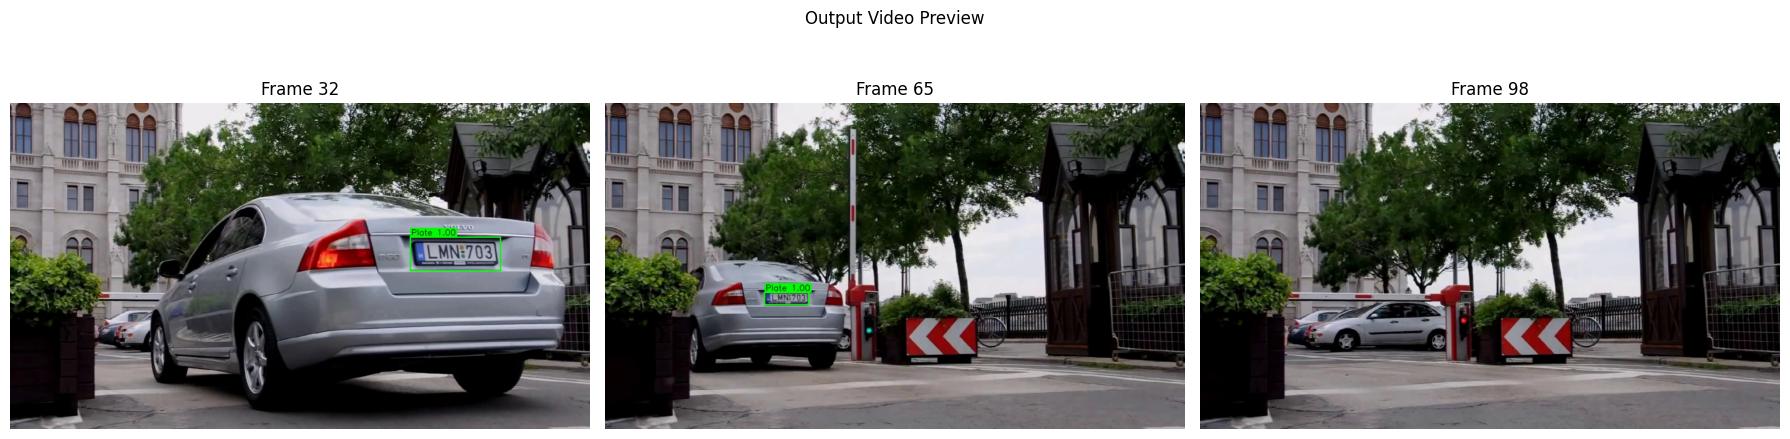

In [17]:
# Preview 3 frames from the output video
if os.path.exists(VIDEO_OUT):
    cap   = cv2.VideoCapture(VIDEO_OUT)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, pos in zip(axes, [total//4, total//2, 3*total//4]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
        ret, frame = cap.read()
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis('off'); ax.set_title(f'Frame {pos}')
    cap.release()
    plt.suptitle('Output Video Preview', fontsize=12)
    plt.tight_layout(); plt.show()

**Output video has been saved to `output_video.mp4`.**

Upload to YouTube (unlisted/public) and paste the link here.

**YouTube link:** *(paste here)*

*(Reference sample output below:)*

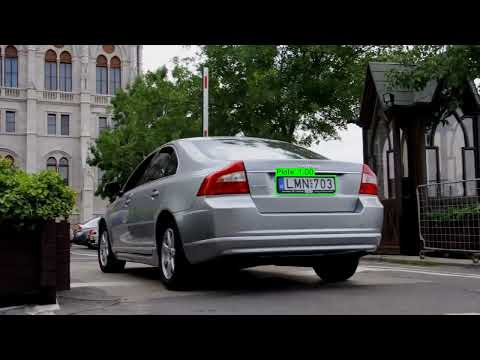

In [21]:
video = YouTubeVideo('DSIJwqNXxpE', width=640, height=360)
display(video)